In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Ustawienie ładnego stylu dla wszystkich wykresów
sns.set_theme(style="whitegrid")

In [2]:
# Wczytanie danych z pliku
df = pd.read_csv('ankieta_chor.csv')

print(f"Liczba wierszy przed czyszczeniem: {len(df)}")
df.head()

Liczba wierszy przed czyszczeniem: 95


,Sygnatura czasowa,Dyrygent ogłasza 10 minut przerwy. Twój standardowy ruch to:,Dyrygent przerywa i mówi: 'Ten fragment brzmi fatalnie w waszym głosie'. Co myślisz?\n,Poziom tremy przed wejściem na scenę:\n,Jaki jest Twój kolor włosów?,"Jak często zdarza Ci się rozmawiać z sąsiadem, gdy dyrygent ćwiczy z innym głosem?"" (Skala 1-10) \n",Strategia w przypadku pomyłki na koncercie:\n,Który opis punktualność Cię najbardziej opisuje:,Jak oceniasz proporcje swojej szyi? (Skala 1-10),Wzrost (w cm):,Co kosztuje Cię więcej fizycznego wysiłku podczas śpiewania?,"Kiedy cały chór śpiewa bardzo głośno (tutti), jak zazwyczaj odczuwasz swój własny głos na tle grupy?",Jakim głosem jesteś:
0,2026-06-04 16:46:21,Wychodzę na zewnątrz / idę coś zjeść lub się n...,"Analizuję technicznie, co dokładnie robimy źle.","Motywujący (lekki dreszczyk emocji, który poma...",Brązowe / Szatyn,6,Śpiewam ciszej i próbuję płynnie wrócić.,Zawsze 5 minut przed czasem,4.0,186.0,"Wejście bardzo wysoko (głos się zaciska, wymag...","Zawsze wyraźnie słyszę swój głos, ""przebija si...",Bas (bas 2)
1,2026-06-04 16:48:04,Wychodzę na zewnątrz / idę coś zjeść lub się n...,"Ja śpiewam dobrze, to reszta psuje.","Zerowy (pełen luz, traktuję to rutynowo).",Brązowe / Szatyn,1,"Uśmiecham się szeroko i udaję, że tak miało być.",Zawsze 5 minut przed czasem,6.0,159.0,"Zejście bardzo nisko (głos traci moc, matowieje).","Często w ogóle siebie nie słyszę, zagłuszają m...",Alt 1
2,2026-06-04 17:06:27,Wychodzę na zewnątrz / idę coś zjeść lub się n...,"Muszę się bardziej skupić, to pewnie też moja ...","Motywujący (lekki dreszczyk emocji, który poma...",Brązowe / Szatyn,6,Śpiewam ciszej i próbuję płynnie wrócić.,Zawsze 5 minut przed czasem,8.0,170.0,"Wejście bardzo wysoko (głos się zaciska, wymag...",Mój głos łatwo wtapia się w brzmienie reszty c...,Baryton (bas 1)
3,2026-06-04 17:11:40,Wychodzę na zewnątrz / idę coś zjeść lub się n...,"Muszę się bardziej skupić, to pewnie też moja ...","Motywujący (lekki dreszczyk emocji, który poma...",Brązowe / Szatyn,5,"Uśmiecham się szeroko i udaję, że tak miało być.",kilka minutek nikogo nigdy nie zbawił,6.0,170.0,"Wejście bardzo wysoko (głos się zaciska, wymag...","Zawsze wyraźnie słyszę swój głos, ""przebija si...",Sopran 2
4,2026-06-04 17:11:43,Idę pogadać z ludźmi z innych sekcji.,"Nic nie myślę, po prostu czekam, aż zaczniemy ...",Paraliżujący (zawsze bardzo się denerwuję).,Blond / Jasne,2,Śpiewam ciszej i próbuję płynnie wrócić.,Studencki kwadrans spóźnienia,8.0,176.0,"Wejście bardzo wysoko (głos się zaciska, wymag...","Często w ogóle siebie nie słyszę, zagłuszają m...",Sopran 2


In [3]:
# 1. Zmiana nazw kolumn na krótkie i wygodne
df.columns = [
    'Czas', 'Przerwa', 'Krytyka', 'Trema', 'Wlosy', 
    'Gadatliwosc', 'Pomylka', 'Punktualnosc', 'Szyja', 
    'Wzrost', 'Wysilek', 'Tutti', 'Glos'
]

# 2. Usunięcie szumu (czasu)
df = df.drop('Czas', axis=1)

# 3. NOWE MAPOWANIE: Podział na głosy wysokie i niskie
voice_mapping = {
    'Sopran 1': 'Głosy wysokie', 'Sopran 2': 'Głosy wysokie',
    'Tenor 1': 'Głosy wysokie', 'Tenor 2': 'Głosy wysokie',
    'Alt 1': 'Głosy niskie', 'Alt 2': 'Głosy niskie',
    'Baryton (bas 1)': 'Głosy niskie', 'Bas (bas 2)': 'Głosy niskie'
}
df['Klasa'] = df['Glos'].map(voice_mapping)

# Usuwamy tylko te wiersze, w których brakuje zmiennej docelowej
df = df.dropna(subset=['Klasa']) 

# 4. Inteligentne uzupełnianie braków (imputacja modą w nowych grupach)
cechy_do_uzupelnienia = df.columns.drop(['Glos', 'Klasa'])
wypelnij_najczestsza = lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
df[cechy_do_uzupelnienia] = df.groupby('Klasa')[cechy_do_uzupelnienia].transform(wypelnij_najczestsza)

# 5. Sprzątanie, podział na X i y oraz One-Hot Encoding
df = df.drop('Glos', axis=1)

y = df['Klasa']
X_raw = df.drop('Klasa', axis=1)
X = pd.get_dummies(X_raw, drop_first=True)

print(f"Dane gotowe! Uratowano ankiety i zachowano {X.shape[0]} rekordów.")
print(f"Wygenerowano {X.shape[1]} cech po One-Hot Encoding.")

Dane gotowe! Uratowano ankiety i zachowano 95 rekordów.
Wygenerowano 25 cech po One-Hot Encoding.


In [4]:
# Modele z włączonym bilansowaniem klas
models = {
    "Drzewo Decyzyjne": DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
    "Las Losowy": RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "SVM (Liniowy)": SVC(class_weight='balanced', kernel='linear', random_state=42)
}

# Walidacja dba o zachowanie proporcji nowych klas wysokie/niskie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- ŚREDNIE WYNIKI Z 5-KROTNEJ WALIDACJI KRZYŻOWEJ (2 KLASY) ---\n")

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=['accuracy', 'f1_macro'])
    
    acc = scores['test_accuracy'].mean()
    acc_std = scores['test_accuracy'].std()
    
    f1 = scores['test_f1_macro'].mean()
    f1_std = scores['test_f1_macro'].std()
    
    print(f"🔥 {name}:")
    print(f"   Accuracy: {acc:.3f} (± {acc_std:.2f})")
    print(f"   F1-Macro: {f1:.3f} (± {f1_std:.3f})\n")

--- ŚREDNIE WYNIKI Z 5-KROTNEJ WALIDACJI KRZYŻOWEJ (2 KLASY) ---

🔥 Drzewo Decyzyjne:
   Accuracy: 0.589 (± 0.02)
   F1-Macro: 0.584 (± 0.022)

🔥 Las Losowy:
   Accuracy: 0.621 (± 0.08)
   F1-Macro: 0.610 (± 0.078)

🔥 SVM (Liniowy):
   Accuracy: 0.600 (± 0.09)
   F1-Macro: 0.595 (± 0.095)



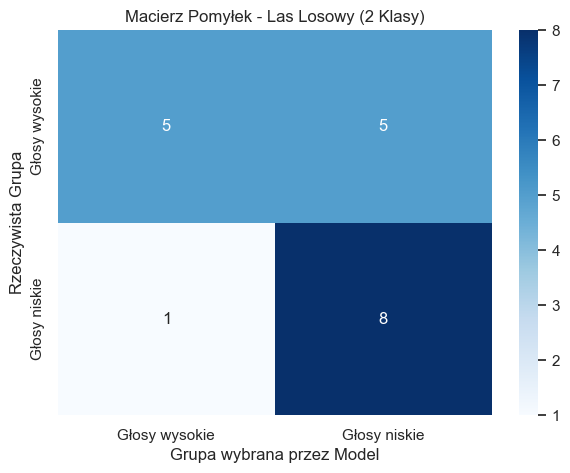


Raport Klasyfikacji:
               precision    recall  f1-score   support

 Głosy niskie       0.62      0.89      0.73         9
Głosy wysokie       0.83      0.50      0.62        10

     accuracy                           0.68        19
    macro avg       0.72      0.69      0.68        19
 weighted avg       0.73      0.68      0.67        19



In [5]:
# Wydzielenie 20% danych na test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Uczymy Las Losowy
best_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Rysowanie heatmapy z nowymi etykietami
klasy_etykiety = ['Głosy wysokie', 'Głosy niskie']
cm = confusion_matrix(y_test, y_pred, labels=klasy_etykiety)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=klasy_etykiety, 
            yticklabels=klasy_etykiety)
plt.ylabel('Rzeczywista Grupa')
plt.xlabel('Grupa wybrana przez Model')
plt.title('Macierz Pomyłek - Las Losowy (2 Klasy)')
plt.show()

print("\nRaport Klasyfikacji:")
print(classification_report(y_test, y_pred))

C:\Users\macie\AppData\Local\Temp\ipykernel_2884\3503979769.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ważność', y='Cecha', data=top_10_features, palette='viridis')


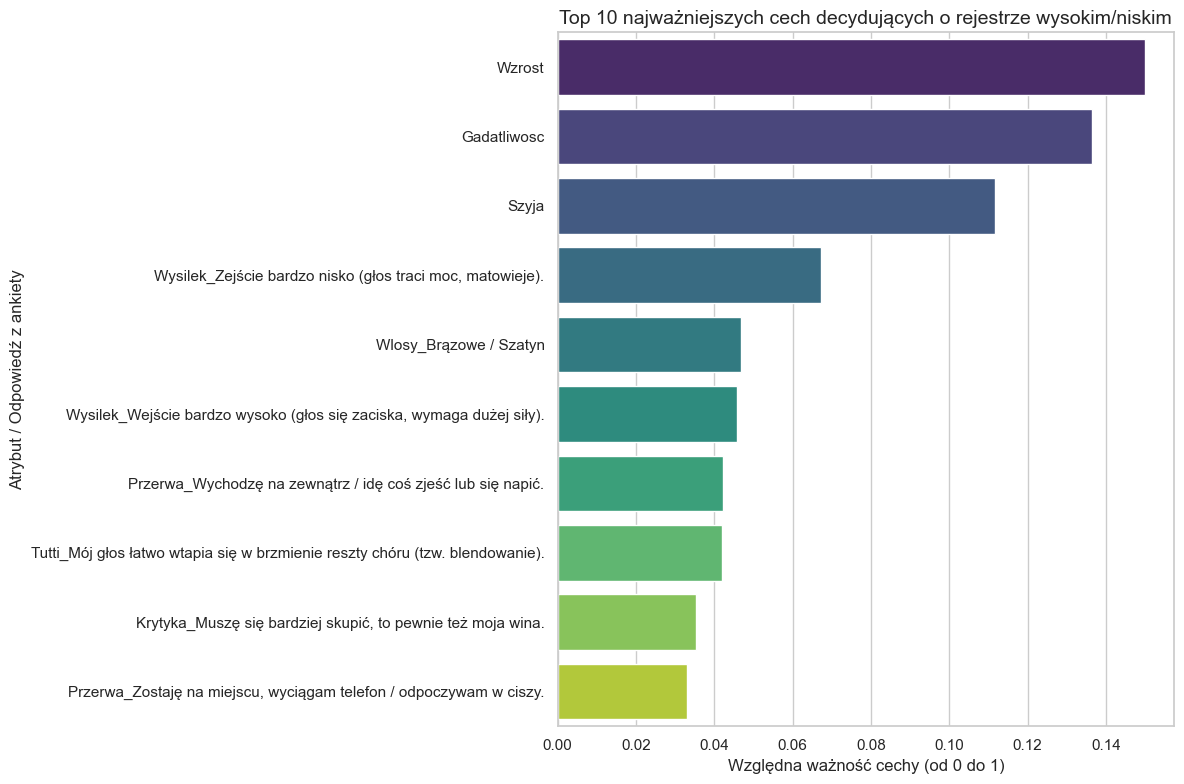

In [6]:
importances = best_model.feature_importances_
feature_names = X_train.columns

feature_imp_df = pd.DataFrame({'Cecha': feature_names, 'Ważność': importances})
feature_imp_df = feature_imp_df.sort_values(by='Ważność', ascending=False)
top_10_features = feature_imp_df.head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x='Ważność', y='Cecha', data=top_10_features, palette='viridis')

plt.title('Top 10 najważniejszych cech decydujących o rejestrze wysokim/niskim', fontsize=14)
plt.xlabel('Względna ważność cechy (od 0 do 1)', fontsize=12)
plt.ylabel('Atrybut / Odpowiedź z ankiety', fontsize=12)
plt.tight_layout()
plt.show()

Generowanie automatycznego raportu wizualnego dla 2 klas...


C:\Users\macie\AppData\Local\Temp\ipykernel_2884\2438899802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Klasa', y=cecha, data=df, palette='Set3', order=srednie.index)


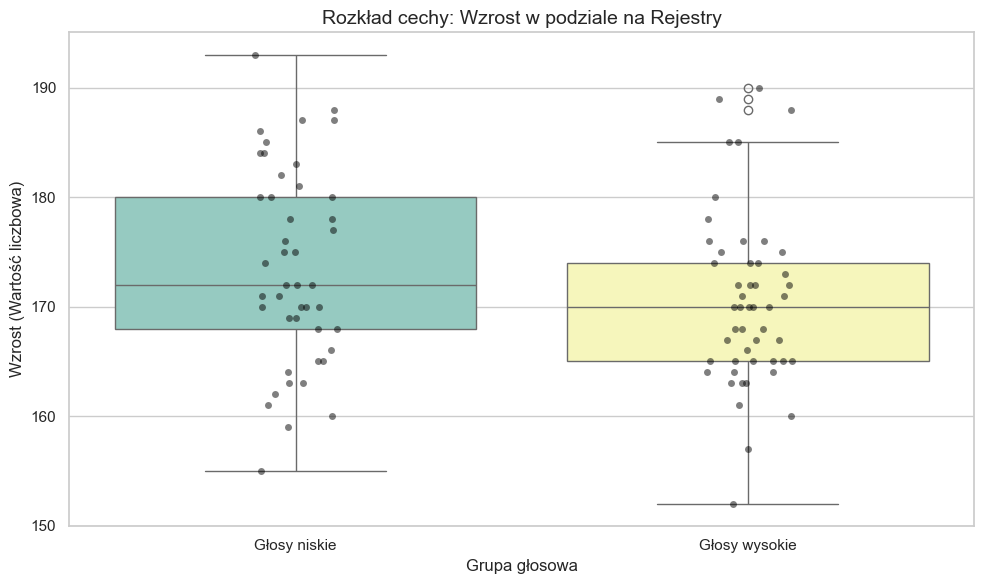

C:\Users\macie\AppData\Local\Temp\ipykernel_2884\2438899802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Klasa', y=cecha, data=df, palette='Set3', order=srednie.index)


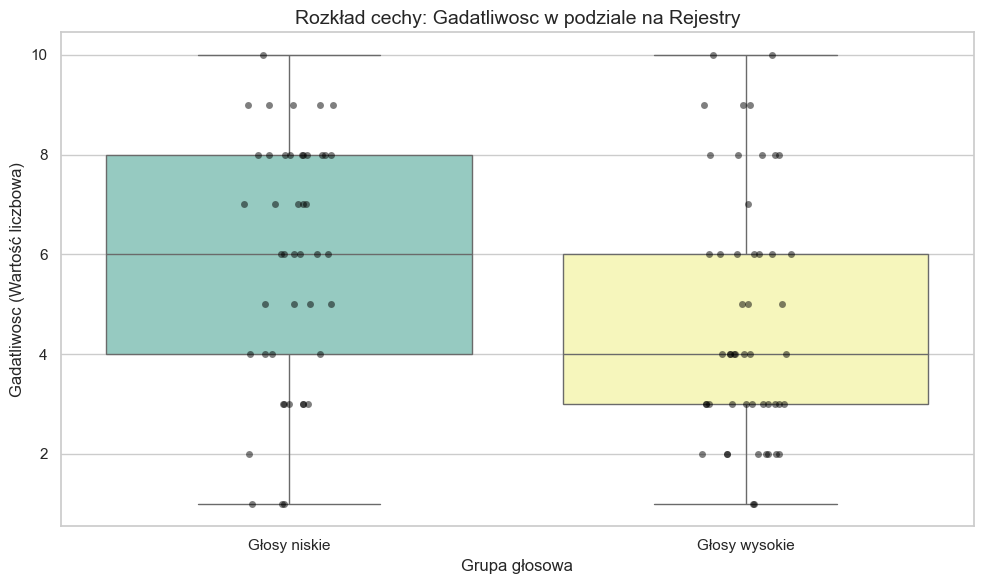

C:\Users\macie\AppData\Local\Temp\ipykernel_2884\2438899802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Klasa', y=cecha, data=df, palette='Set3', order=srednie.index)


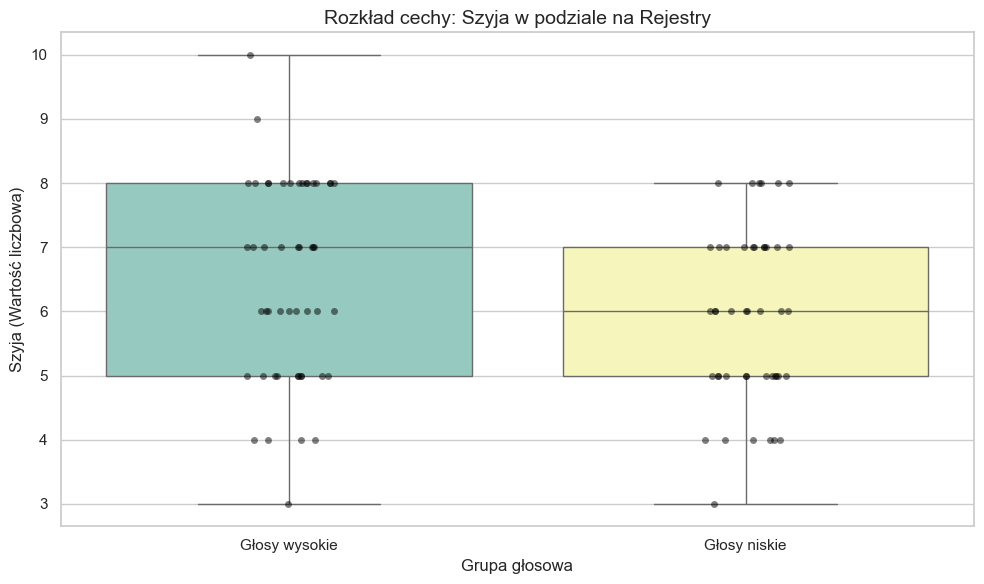

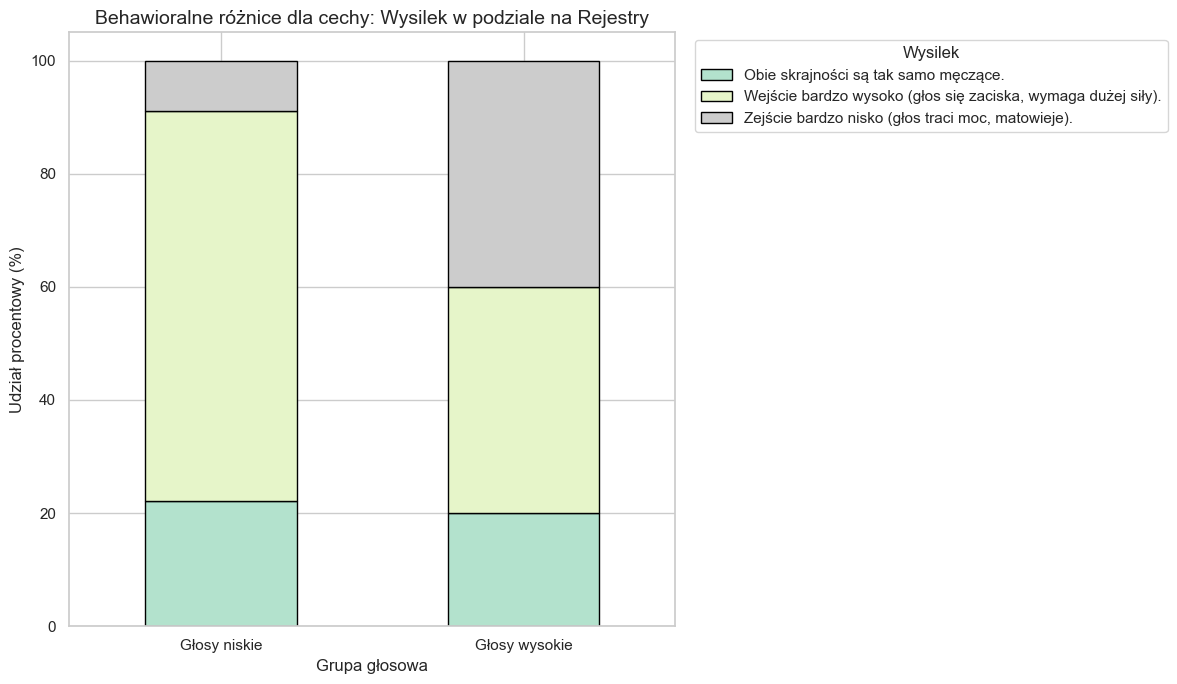

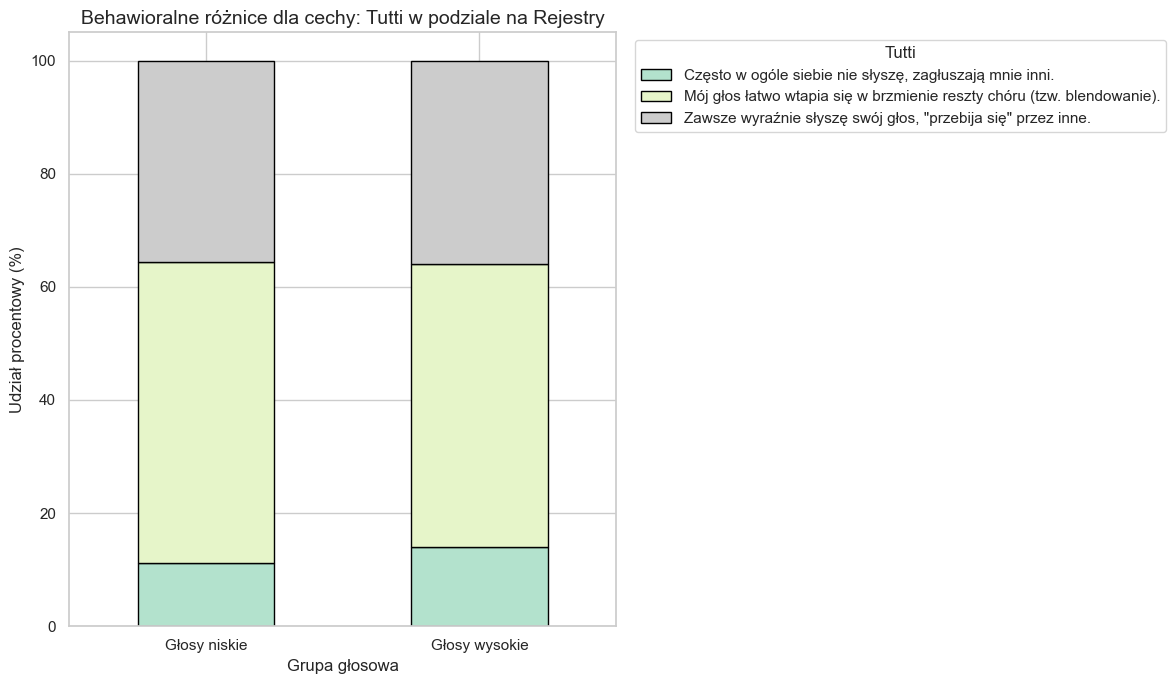

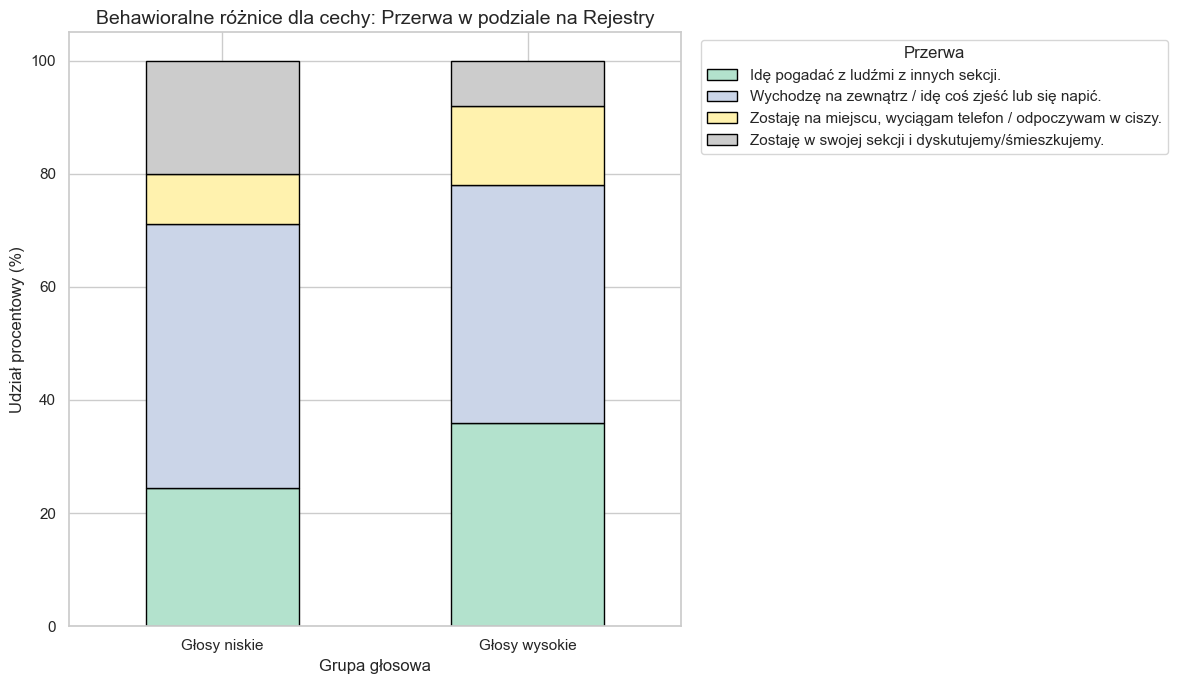

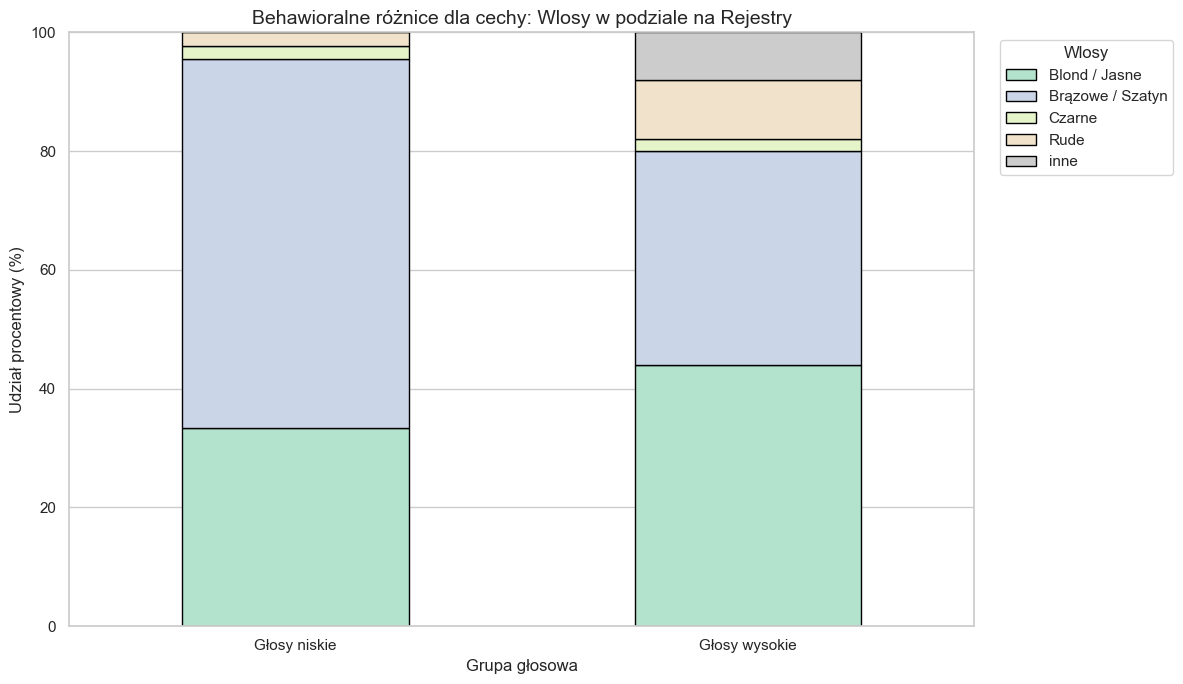

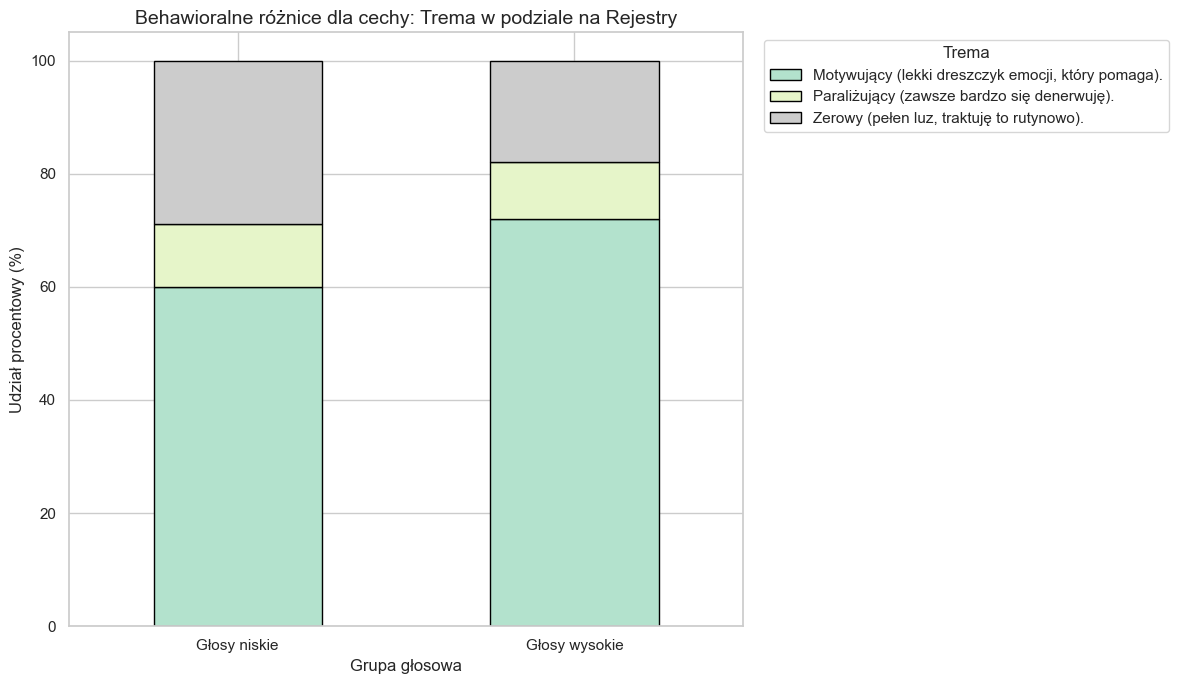

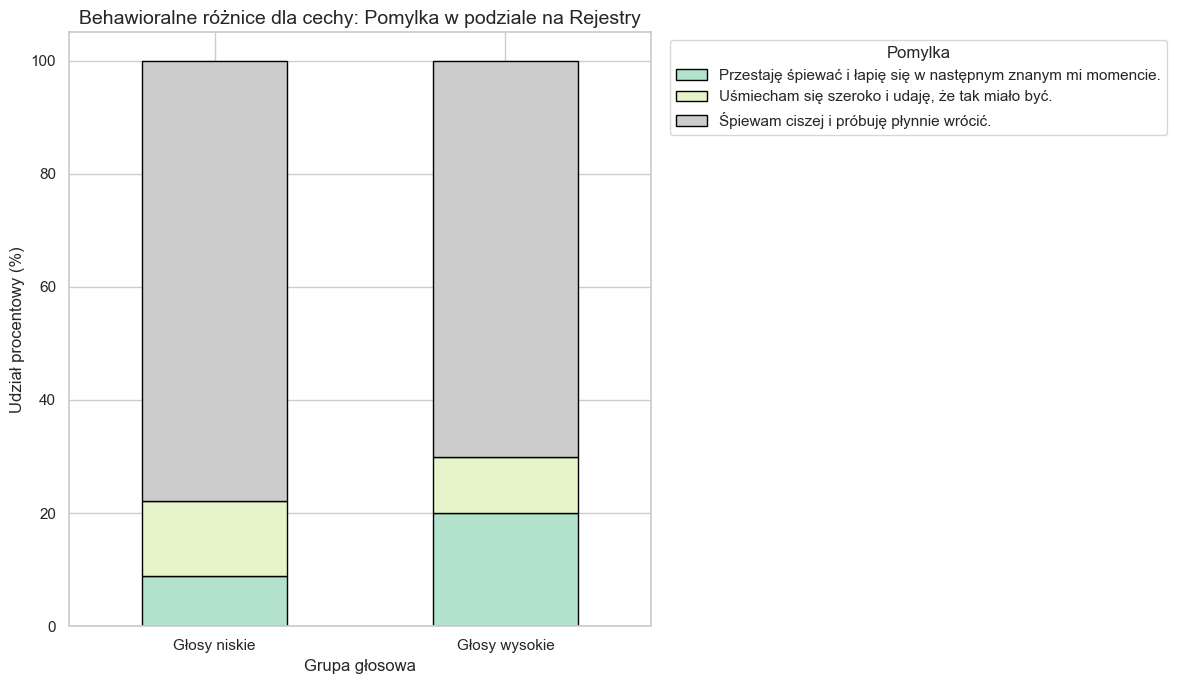

In [7]:
top_cechy_oryginalne = [
    'Wzrost', 'Gadatliwosc', 'Szyja', 'Wysilek', 
    'Tutti', 'Przerwa', 'Wlosy', 'Trema', 'Pomylka'
]

print("Generowanie automatycznego raportu wizualnego dla 2 klas...")
print("=" * 50)

for cecha in top_cechy_oryginalne:
    if pd.api.types.is_numeric_dtype(df[cecha]):
        plt.figure(figsize=(10, 6))
        srednie = df.groupby('Klasa')[cecha].mean().sort_values(ascending=False)
        sns.boxplot(x='Klasa', y=cecha, data=df, palette='Set3', order=srednie.index)
        sns.stripplot(x='Klasa', y=cecha, data=df, color='black', alpha=0.5, jitter=True, order=srednie.index)
        
        plt.title(f'Rozkład cechy: {cecha} w podziale na Rejestry', fontsize=14)
        plt.xlabel('Grupa głosowa', fontsize=12)
        plt.ylabel(f'{cecha} (Wartość liczbowa)', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        tabela = pd.crosstab(df['Klasa'], df[cecha], normalize='index') * 100
        tabela.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='Pastel2', edgecolor='black')
        
        plt.title(f'Behawioralne różnice dla cechy: {cecha} w podziale na Rejestry', fontsize=14)
        plt.xlabel('Grupa głosowa', fontsize=12)
        plt.ylabel('Udział procentowy (%)', fontsize=12)
        plt.legend(title=cecha, bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

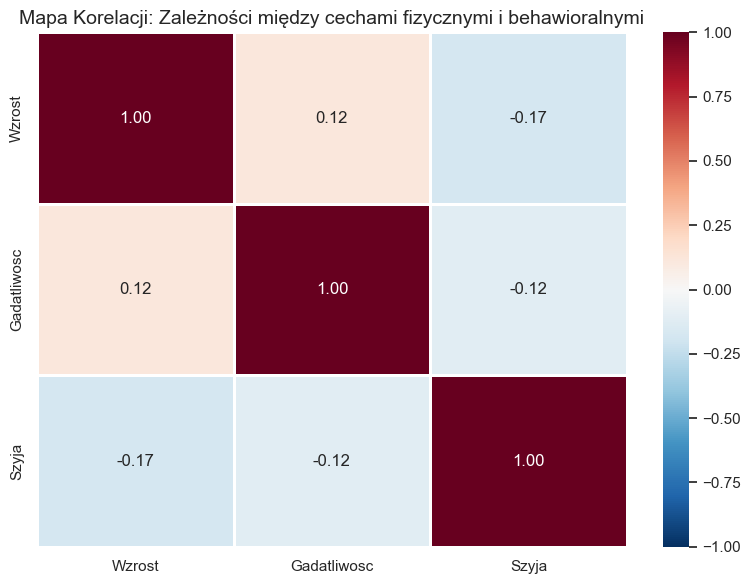

In [8]:
kolumny_liczbowe = ['Wzrost', 'Gadatliwosc', 'Szyja']
df_num = df[kolumny_liczbowe]

korelacje = df_num.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelacje, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, 
            fmt='.2f', linewidths=1, linecolor='white')

plt.title('Mapa Korelacji: Zależności między cechami fizycznymi i behawioralnymi', fontsize=14)
plt.tight_layout()
plt.show()

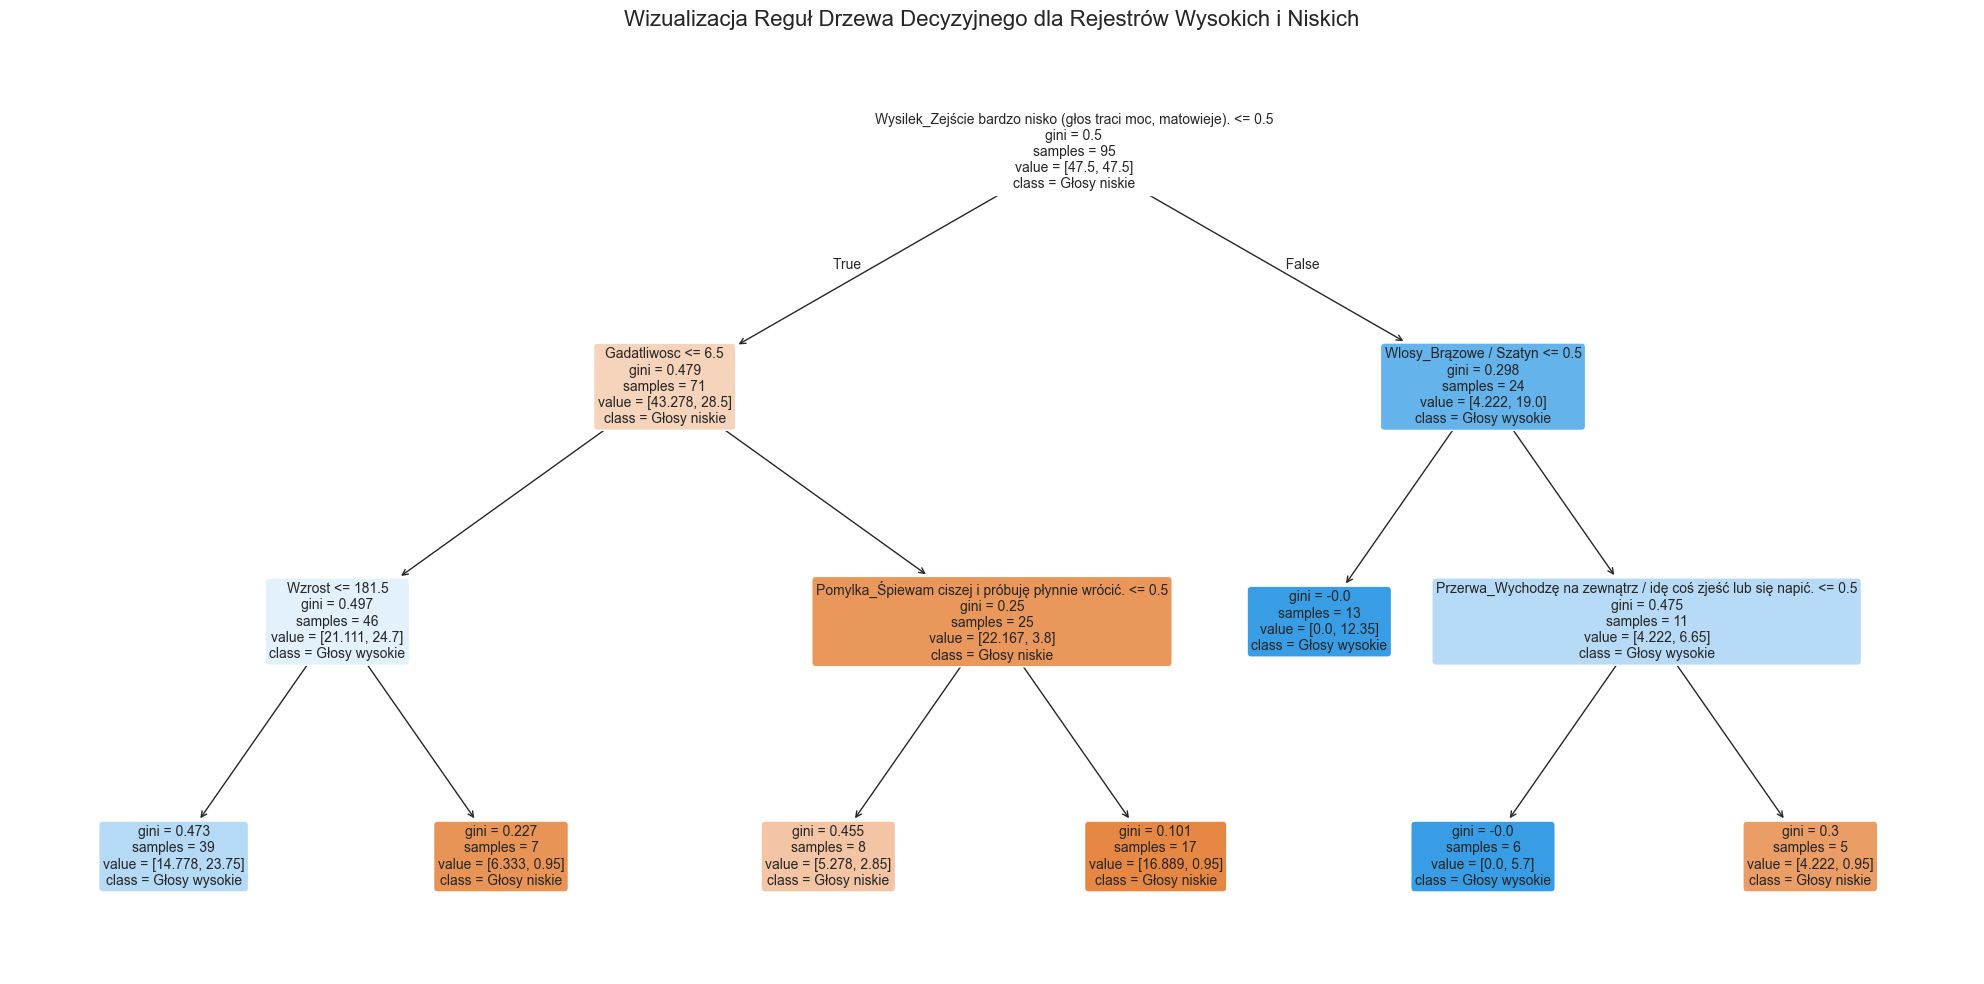

In [9]:
# Drzewo uczone pod podział na 2 grupy
proste_drzewo = DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)
proste_drzewo.fit(X, y)

plt.figure(figsize=(20, 10))
plot_tree(proste_drzewo, 
          feature_names=X.columns, 
          class_names=proste_drzewo.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title('Wizualizacja Reguł Drzewa Decyzyjnego dla Rejestrów Wysokich i Niskich', fontsize=16)
plt.tight_layout()
plt.show()